# Zadanie: baza filmów

Import niezbednych bibliotek

In [211]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

Pobieranie bazy filmów i sprawdzenie ewentualnych braków w danych

Axes(0.125,0.11;0.698618x0.77)


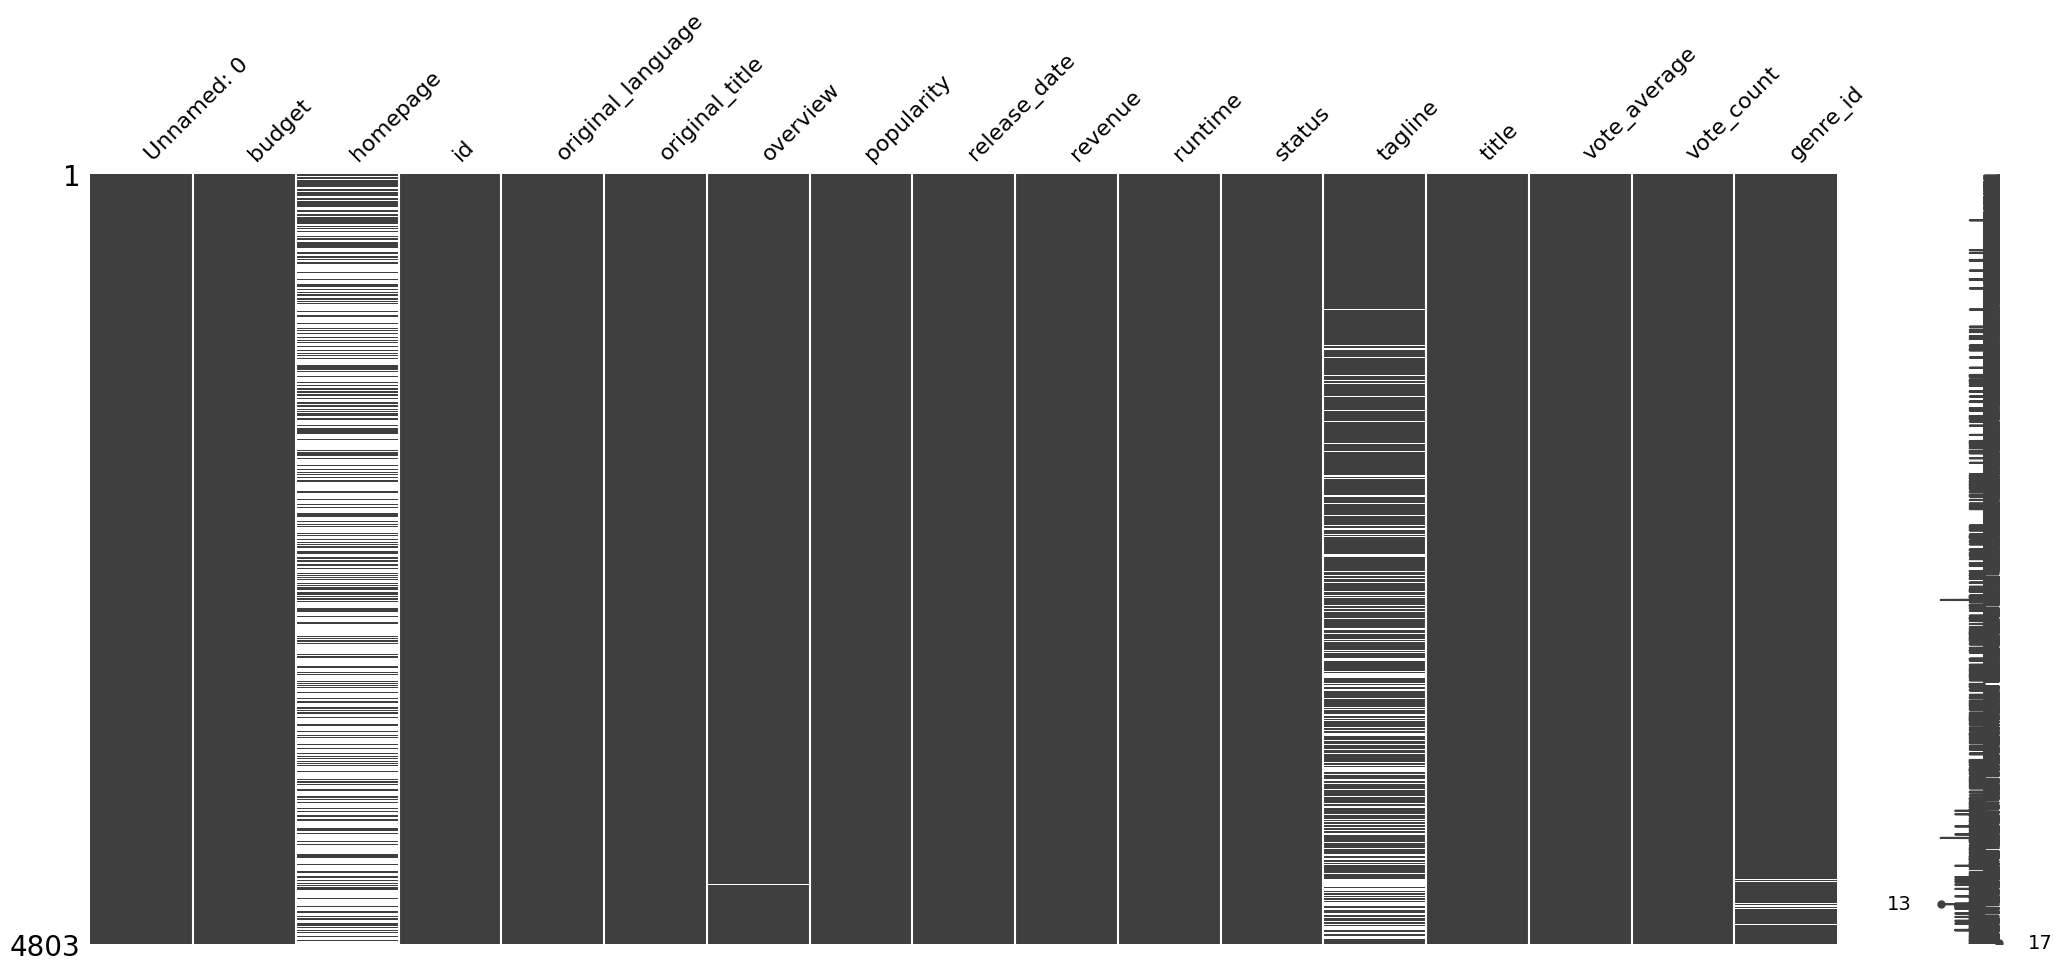

In [212]:
movies_df = pd.read_csv('tmdb_movies.csv')
print(msno.matrix(movies_df))

Pobranie bazy gatunków.

In [213]:
genres_df = pd.read_csv('tmdb_genres.csv')


**AD 1**  
Stworzenie ad_1_df zawierającej filmy których liczba głosów (vote_count) jest większa od 3. kwartyla rozkładu liczby głosów, oraz wyświetlenie listy 10 najelpszych pod względem (vote_average)

In [214]:
ad_1_df = movies_df[movies_df['vote_count'] >= movies_df['vote_count'].quantile(0.75)]
ad_1_df = ad_1_df.sort_values(by='vote_average', ascending=False)
ad_1_df[['original_title', 'vote_average', 'vote_count']].head(10)


,original_title,vote_average,vote_count
1881,The Shawshank Redemption,8.5,8205
3337,The Godfather,8.4,5893
3865,Whiplash,8.3,4254
1818,Schindler's List,8.3,4329
2294,千と千尋の神隠し,8.3,3840
2731,The Godfather: Part II,8.3,3338
3232,Pulp Fiction,8.3,8428
662,Fight Club,8.3,9413
1990,The Empire Strikes Back,8.2,5879
690,The Green Mile,8.2,4048


**AD 2**
zmiana typu danych w kolumnie 'release_date' na typ data. Odfiltrowanie z bazy filmów których premiara zawierała sie w przedziale 2010-2016.

In [215]:
ad_2_df = movies_df.copy()
ad_2_df['release_date'] = pd.to_datetime(ad_2_df['release_date'])
ad_2_df = ad_2_df[ad_2_df['release_date'].dt.year.between(2010, 2016)]
ad_2_df['release_date'] = ad_2_df['release_date'].dt.year

Przekształcenie tabeli i przygotowanie danych do wyświetlenia

In [216]:
ad_2_df = ad_2_df.pivot_table(values=['revenue','budget'],index='release_date',aggfunc=np.mean)

Funkcja pomocnicza przy formatowaniu danych

In [217]:
def million(x, pos):
        return '{:2.1f}M'.format(x*1e-6)

Tworzenie wykresu zgodnego z treścia zadania. Przedstawiajacego średnbi przychód i budżet w latach 2010-2016

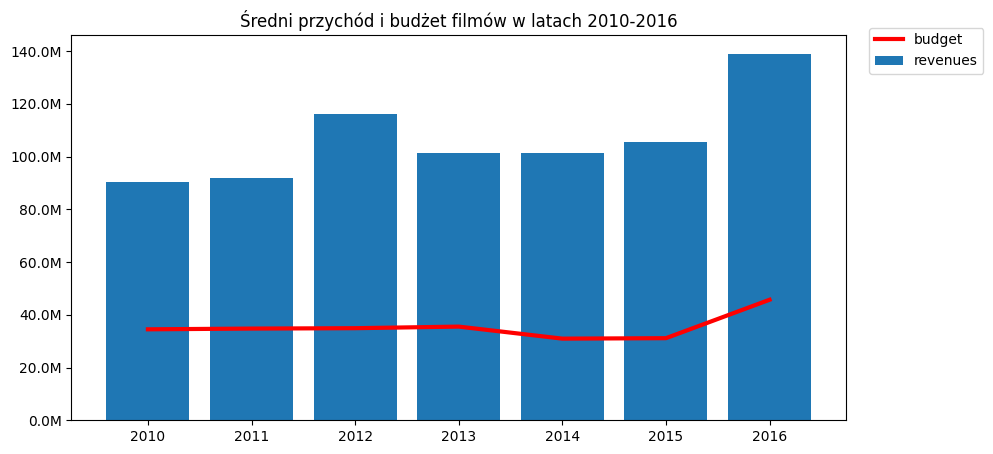

In [218]:
fig, ax = plt.subplots(figsize=(10, 5))
formatter = plt.FuncFormatter(million)

ax.yaxis.set_major_formatter(formatter)
ax.set_title('Średni przychód i budżet filmów w latach 2010-2016') 

ax.bar(ad_2_df.index, ad_2_df['revenue'], label='revenues')
ax.plot(ad_2_df.index, ad_2_df['budget'], color='red', linewidth=3, label='budget')
ax.legend(loc=(1.03, 0.9))
plt.show()

W latach 2010-2015 widzimy ogolny trend wzrostowy zysków przy jednoczesnym utrzymaniu średniego budżetu na podobnym poziomie, w roku 2016 wraz ze wzrostem średniego  budżetu znacząco wzrosły też średnie zyski.

**AD 3**
Zmiana nazwy kolumny w tabeli genres_df, w celu przygotowania do marge.

In [219]:
genres_df.rename(columns={'Unnamed: 0':'genre_id'}, inplace=True)


Stworzenie bazy filmowej ad_3_df poprzez połaczenie movies_df oraz genres_df. 

In [220]:
ad_3_df = pd.merge(movies_df, genres_df, on='genre_id')

**AD 4**  
Stworzenie tabeli ad_4_df zawierajacej liczbe wystąpień danych gatunków w bazie danych, oraz wyświetlenie najpopularniejszego gatunku wraz z liczbą wystąpień.

In [221]:
ad_4_df  = ad_3_df['genres'].value_counts()
print(f'Najczęściej występujacym gatunkiem w bazie jest: {ad_4_df.index[0]}. Liczba wystąpień: {ad_4_df.iloc[0]}')

Najczęściej występujacym gatunkiem w bazie jest: Drama. Liczba wystąpień: 1207


**AD 5**  
Stworzenie tabeli ad_5_df zawierajacej średni czas trwania filmów w każdym gatunku oraz wyświetlenie nazwy gatunku który średnio trwa najdłużej wraz ze średnim czasem dla tego gatunku

In [222]:
ad_5_df = ad_3_df.pivot_table(values=['runtime'],index='genres',aggfunc=np.mean)
print(f"Średnia najdłużej trwają filmy z gatunku: {ad_5_df['runtime'].idxmax()}. Średnio ich długośc wynosi: {ad_5_df['runtime'].max()}")

Średnia najdłużej trwają filmy z gatunku: History. Średnio ich długośc wynosi: 133.96


**AD 6**  
Stworzenie listy filmów należących do gatunku którego filmy średnio trwają najdłużej.

In [223]:
ad_6_df = ad_3_df[ad_3_df['genres'] == ad_5_df['runtime'].idxmax()]


Tworzenie histogramu przedstawiajacego przedstawiajacego czas trwania filmów z gatunku którego filmy średnio trwają najdłużej.

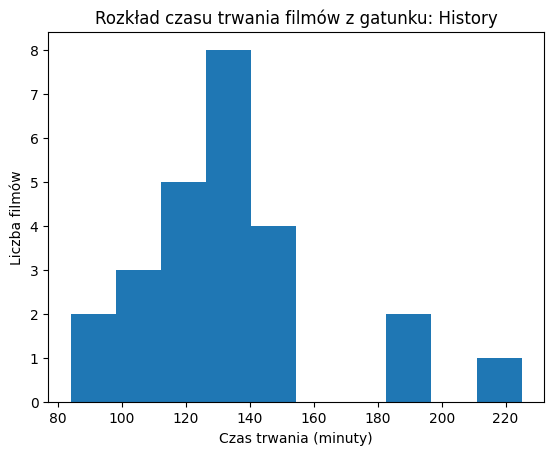

In [224]:
plt.hist(ad_6_df['runtime'])

plt.title(f'Rozkład czasu trwania filmów z gatunku: {ad_5_df['runtime'].idxmax()}')
plt.xlabel('Czas trwania (minuty)')
plt.ylabel('Liczba filmów')

plt.show()